In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install xgboost lightgbm statsmodels

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA

In [5]:
df= pd.read_csv("/content/drive/MyDrive/K_class_sales_clean (1).csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,Tier 2,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [6]:
print(df.shape)

(8523, 13)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Profit                     8523 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage:

In [8]:
print(df.columns)

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Profit'],
      dtype='object')


In [9]:
print("missing values in each coloumn:")
df.isnull().sum()

missing values in each coloumn:


,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


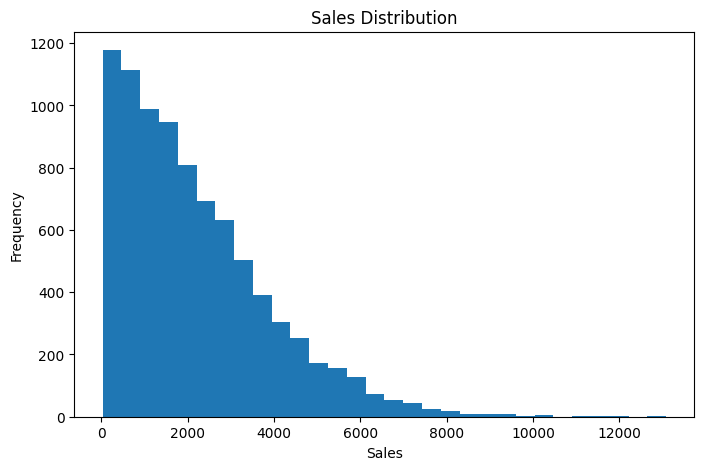

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Item_Outlet_Sales'], bins=30)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

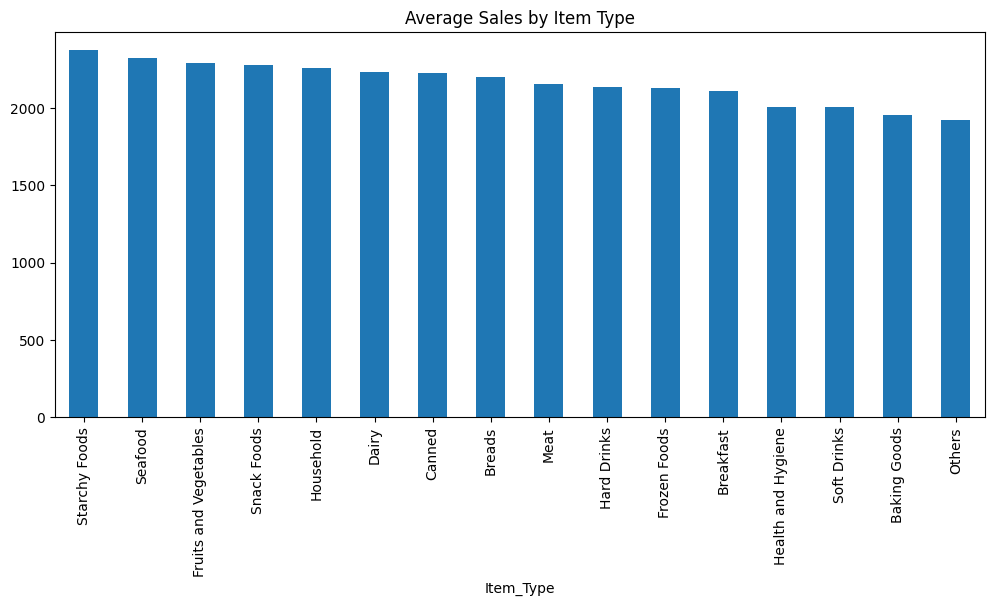

In [11]:
sales_by_type = df.groupby('Item_Type')['Item_Outlet_Sales'].mean()

sales_by_type.sort_values(ascending=False).plot(kind='bar',figsize=(12,5))
plt.title('Average Sales by Item Type')
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [13]:
cat_cols = [
    'Item_Identifier',
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
cat_cols

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [15]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,156,9.30,1,0.016047,4,249.8,9,1999,1,0,1,3735.1380,11.5
1,8,5.92,2,0.019278,14,48.3,3,2009,1,0,2,443.4228,14.3
2,662,17.50,1,0.016760,10,141.6,9,1999,1,0,1,2097.2700,14.5
3,1121,19.20,2,0.000000,6,182.1,0,1998,1,0,0,732.3800,13.6
4,1297,8.93,1,0.000000,9,53.9,1,1987,0,1,1,994.7052,14.1


In [16]:
df = df.drop('Item_Identifier', axis=1)
x= df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [17]:
print("Shape of features (x):", x.shape)
print("Shape of target (y):", y.shape)

Shape of features (x): (8523, 11)
Shape of target (y): (8523,)


In [18]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-0.42651074, -0.57284357, -0.97073217, ..., -0.75754724,
        -0.25265831, -1.12503308],
       [-1.03017327,  0.97809218, -0.90811123, ..., -0.75754724,
         1.00297245,  0.52034176],
       [ 1.03799599, -0.57284357, -0.95691733, ..., -0.75754724,
        -0.25265831,  0.63786854],
       ...,
       [-0.19433284, -0.57284357, -0.59978449, ...,  1.50474258,
        -0.25265831, -2.30030082],
       [-0.79978136,  0.97809218,  1.53287976, ..., -0.75754724,
         1.00297245,  0.46157837],
       [ 0.55578036, -0.57284357, -0.41193591, ...,  1.50474258,
        -0.25265831,  0.69663192]])

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
y_test

,Item_Outlet_Sales
7503,1743.0644
2957,356.8688
7031,377.5086
1084,5778.4782
856,2356.9320
...,...
7205,3004.0896
3257,890.8404
6346,629.1810
6318,253.0040


In [21]:
y_train

,Item_Outlet_Sales
549,2386.2272
7757,3103.9596
764,1125.2020
6867,284.2966
2716,4224.5010
...,...
5734,280.9676
5191,1301.6390
5390,6145.3340
860,1649.8524


In [22]:
x_test

array([[ 0.46648117, -0.57284357, -0.77202035, ...,  0.37359767,
        -0.25265831,  0.3440516 ],
       [-0.67119052, -0.57284357,  0.09698345, ...,  1.50474258,
        -0.25265831, -1.83019373],
       [ 0.50220085,  0.97809218, -0.48103352, ..., -0.75754724,
        -0.25265831,  0.22652483],
       ...,
       [ 0.50220085,  0.97809218, -0.48294179, ...,  0.37359767,
        -0.25265831,  0.3440516 ],
       [-0.33721155,  0.97809218,  1.454639  , ..., -0.75754724,
         1.00297245,  0.3440516 ],
       [-0.67565548, -0.57284357, -0.21385093, ..., -0.75754724,
        -0.25265831,  0.57910515]])

In [23]:
x_train

array([[-0.39079106,  0.97809218, -0.5994047 , ..., -0.75754724,
        -0.25265831, -2.94669808],
       [ 1.12729519, -0.57284357, -0.36164295, ..., -0.75754724,
        -0.25265831,  0.63786854],
       [ 1.05585583,  0.97809218,  0.19362035, ...,  1.50474258,
        -0.25265831,  0.28528821],
       ...,
       [ 1.05585583, -0.57284357, -0.91459541, ..., -0.75754724,
        -0.25265831,  0.46157837],
       [ 1.54700138,  2.52902792, -0.22811087, ..., -0.75754724,
        -0.25265831, -0.18481889],
       [ 0.83260785, -2.12377931, -0.95239887, ...,  1.50474258,
        -0.25265831, -0.94874292]])

In [24]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [25]:
c=lr.intercept_
c

np.float64(2185.5923935550704)

In [26]:
m=lr.coef_
m

array([-1.12513736e+01,  2.31965176e+01, -5.59880410e+01, -4.54152566e-02,
        9.68879339e+02,  3.32170042e+02,  1.00808501e+02, -3.98233764e+02,
        2.93957391e+02,  6.81585057e+02, -1.56087943e+01])

In [27]:
y_pred=lr.predict(x_test)
y_pred

array([1394.34374129,  766.94054592,  918.68444288, ...,  831.6905453 ,
       1223.97972844, 1723.28427794])

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE:",mean_absolute_error(y_test,y_pred))
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mean_squared_error(y_test,y_pred))
mse=mean_squared_error(y_test,y_pred)
rmse=mse**.5
r2 = r2_score(y_test, y_pred)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 847.9692724232059
MSE: 1276470.6997716946
RMSE: 1129.8100281780537
R2: 0.5303588087853296


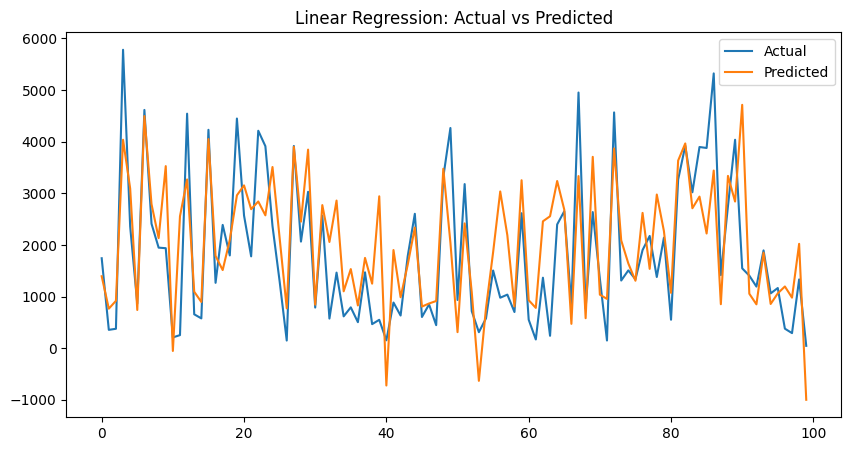

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

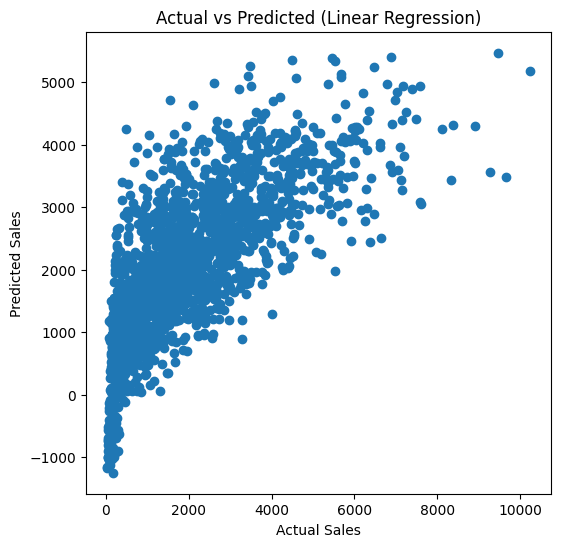

In [30]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [31]:
dt = DecisionTreeRegressor(
    random_state=42
)

In [32]:
dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [33]:
dt_pred = dt.predict(x_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, dt_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, dt_pred))
r2_dt = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
MAE : 1031.176982052786
RMSE: 1498.6271346938343
R²  : 0.17369094074082858


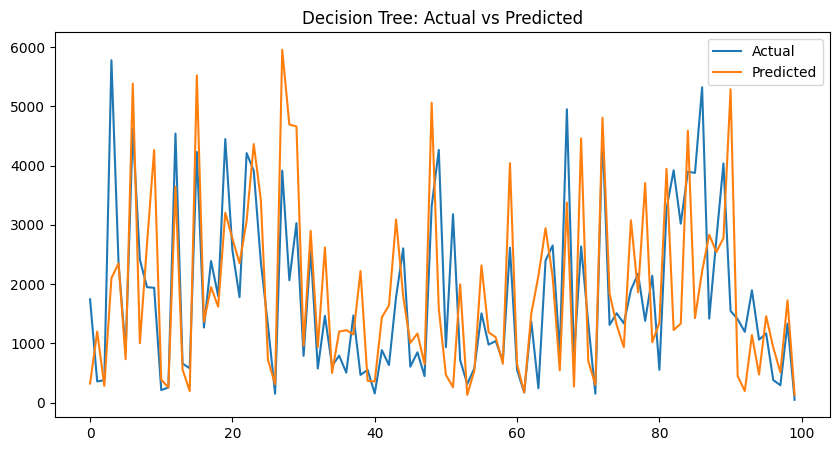

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(dt_pred[:100], label="Predicted")

plt.title("Decision Tree: Actual vs Predicted")
plt.legend()
plt.show()

In [36]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [37]:
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
xgb_pred = xgb.predict(x_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Results
MAE : 734.2997035243775
RMSE: 1054.8552478833135
R²  : 0.5906063839135436


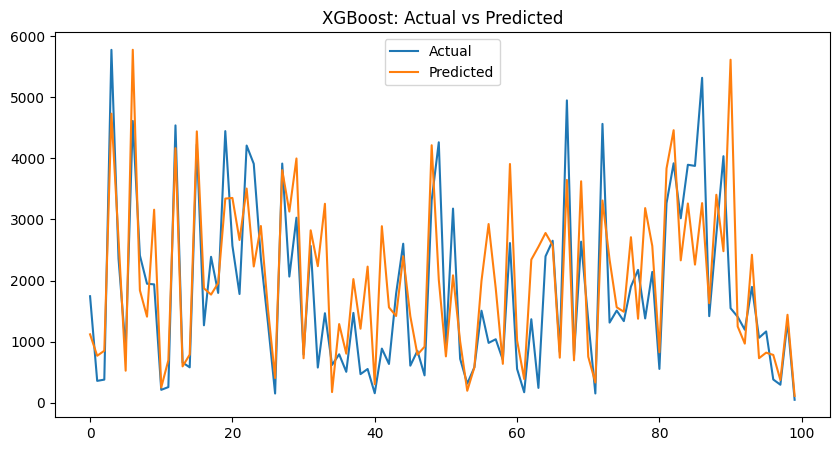

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(xgb_pred[:100], label="Predicted")

plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.show()

In [41]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [42]:
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [43]:
rf_pred = rf.predict(x_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 748.4189462756598
RMSE: 1070.1401614245658
R²  : 0.5786561525604588


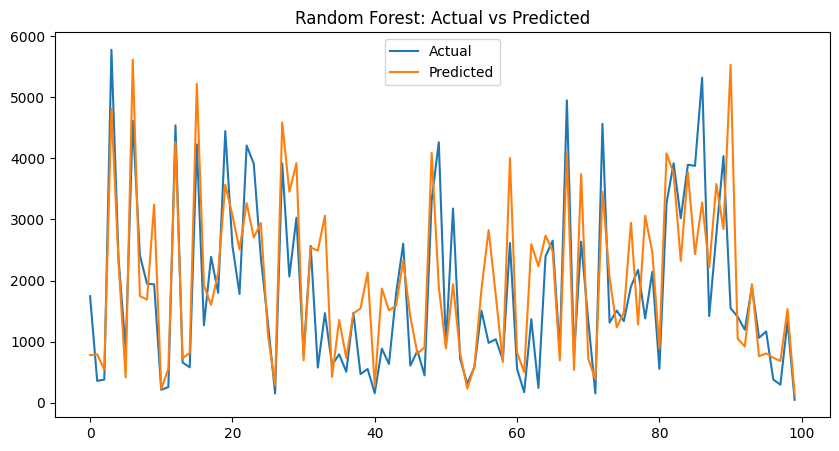

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(rf_pred[:100], label="Predicted")

plt.title("Random Forest: Actual vs Predicted")
plt.legend()
plt.show()

In [46]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_xgb
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,847.969272,1129.810028,0.530359
1,Decision Tree,1031.176982,1498.627135,0.173691
2,Random Forest,748.418946,1070.140161,0.578656
3,XGBoost,734.299704,1054.855248,0.590606


In [47]:
import matplotlib.pyplot as plt

n = 100  # first 100 samples

y_true = y_test.values[:n]

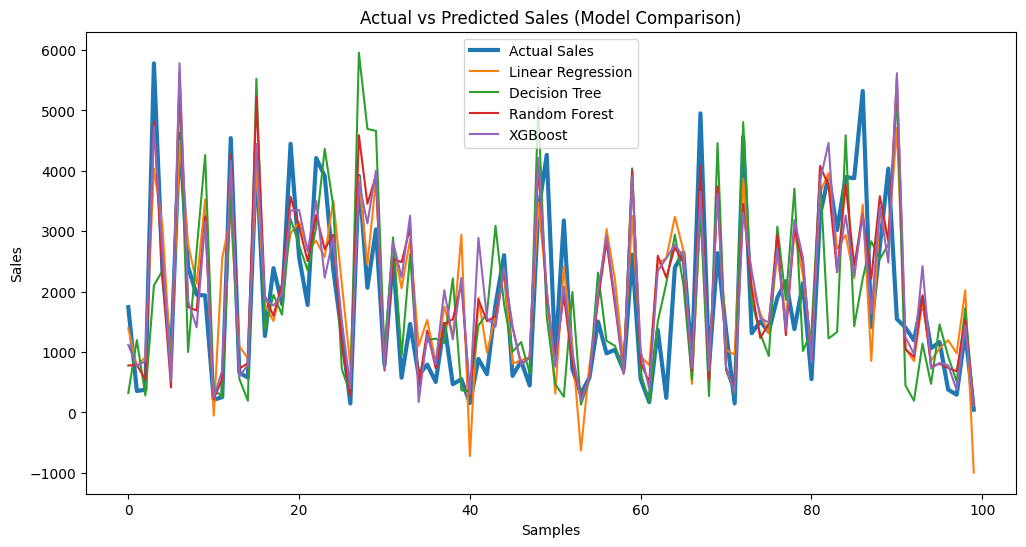

In [48]:
plt.figure(figsize=(12,6))

plt.plot(y_true, label="Actual Sales", linewidth=3)

plt.plot(y_pred[:n], label="Linear Regression")
plt.plot(dt_pred[:n], label="Decision Tree")
plt.plot(rf_pred[:n], label="Random Forest")
plt.plot(xgb_pred[:n], label="XGBoost")

plt.title("Actual vs Predicted Sales (Model Comparison)")
plt.xlabel("Samples")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"]

r2_scores = [r2, r2_dt, r2_rf, r2_xgb]

eff_df = pd.DataFrame({
    "Model": models,
    "R2 Score": r2_scores
})

eff_df

,Model,R2 Score
0,Linear Regression,0.530359
1,Decision Tree,0.173691
2,Random Forest,0.578656
3,XGBoost,0.590606


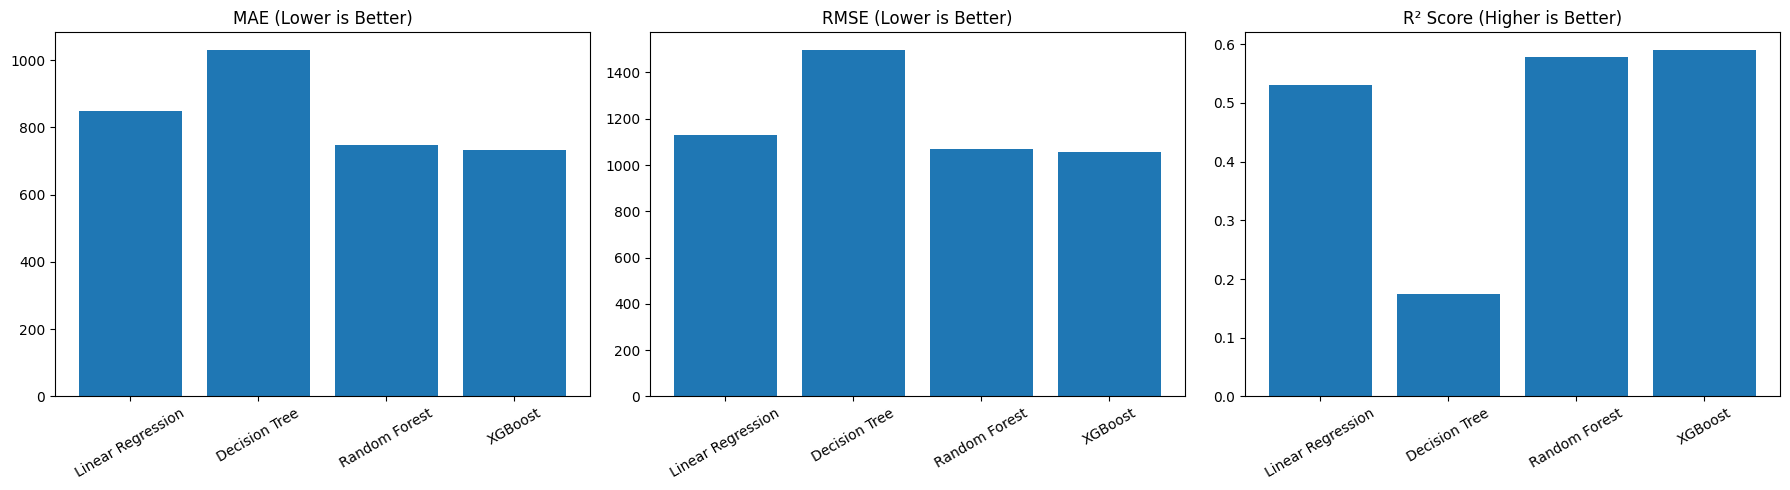

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "MAE": [mae, mae_dt, mae_rf, mae_xgb],
    "RMSE": [rmse, rmse_dt, rmse_rf, rmse_xgb],
    "R2": [r2, r2_dt, r2_rf, r2_xgb]
})

fig, ax = plt.subplots(1, 3, figsize=(18,5))

# MAE
ax[0].bar(results["Model"], results["MAE"])
ax[0].set_title("MAE (Lower is Better)")
ax[0].tick_params(axis='x', rotation=30)

# RMSE
ax[1].bar(results["Model"], results["RMSE"])
ax[1].set_title("RMSE (Lower is Better)")
ax[1].tick_params(axis='x', rotation=30)

# R2
ax[2].bar(results["Model"], results["R2"])
ax[2].set_title("R² Score (Higher is Better)")
ax[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

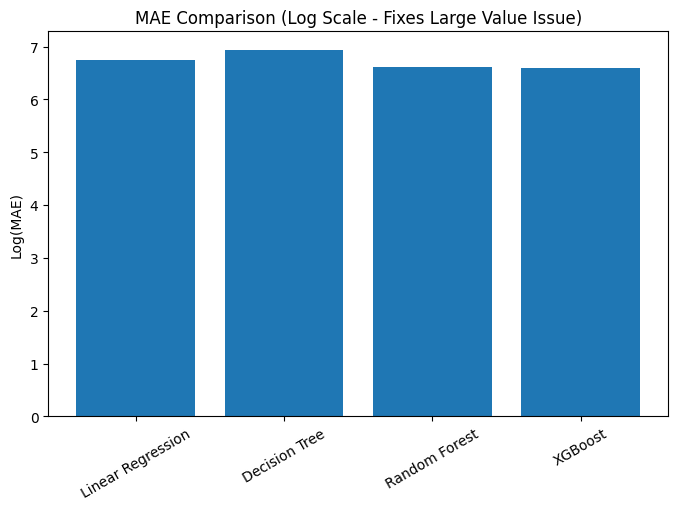

In [51]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"]
mae_values = [mae, mae_dt, mae_rf, mae_xgb]

plt.figure(figsize=(8,5))

plt.bar(models, np.log1p(mae_values))

plt.title("MAE Comparison (Log Scale - Fixes Large Value Issue)")
plt.ylabel("Log(MAE)")
plt.xticks(rotation=30)

plt.show()

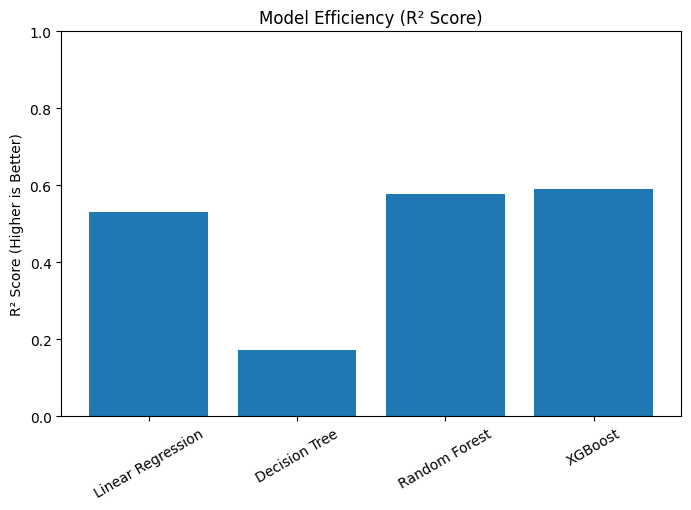

In [52]:
r2_values = [r2, r2_dt, r2_rf, r2_xgb]

plt.figure(figsize=(8,5))

plt.bar(models, r2_values)

plt.title("Model Efficiency (R² Score)")
plt.ylabel("R² Score (Higher is Better)")
plt.xticks(rotation=30)

plt.ylim(0,1)

plt.show()

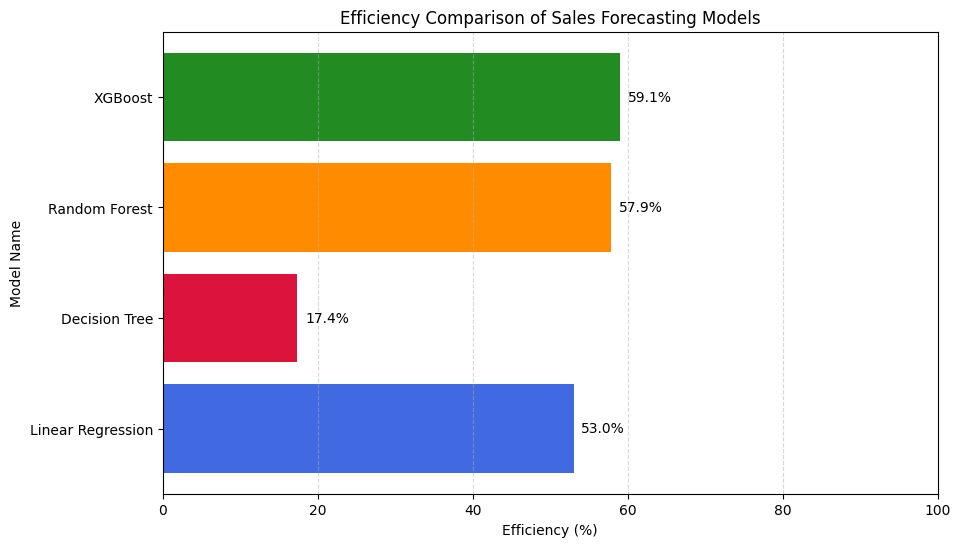

In [53]:
import matplotlib.pyplot as plt

models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

efficiency = [
    r2* 100,
    r2_dt * 100,
    r2_rf * 100,
    r2_xgb * 100
]

colors = ['royalblue','crimson','darkorange','forestgreen']

plt.figure(figsize=(10,6))

bars = plt.barh(models,efficiency,color=colors)

plt.xlabel("Efficiency (%)")
plt.ylabel("Model Name")
plt.title("Efficiency Comparison of Sales Forecasting Models")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va='center'
    )

plt.xlim(0,100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()